In [5]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

In [6]:
# Load Dataset
df = pd.read_csv("../data/player_features_final.csv")

In [7]:
# Dataset Shape
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 11080
Columns : 35


In [9]:
# First Five Rows
df.head()

,pid,age,gender,country,login_count_24h,repeat_login_count_24h,active_days_24h,avg_login_gap_minutes,jobs_started_24h,unique_jobs_started_24h,...,max_session_length,distinct_jobs_played,interruption_count,avg_interruption_session,longest_interrupted_session,career_play_ratio,special_play_ratio,freeplay_ratio,challenge_ratio,retained
0,p10032,35.0,Female,USA,1,0,1,0.0,2,2,...,5,2,2,17.5,30,1.0,0.0,0.0,0.0,1
1,p10033,18.0,Male,UK,1,0,1,0.0,2,2,...,8,2,2,8.5,9,1.0,0.0,0.0,0.0,0
2,p4777,44.0,Male,USA,0,0,0,0.0,0,0,...,0,0,0,0.0,0,0.0,0.0,0.0,0.0,1
3,p6114,40.0,Male,Taiwan,1,0,1,0.0,0,0,...,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0
4,p7611,47.0,Male,USA,0,0,0,0.0,0,0,...,0,0,0,0.0,0,0.0,0.0,0.0,0.0,0


In [11]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11080 entries, 0 to 11079
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   pid                           11080 non-null  object 
 1   age                           10964 non-null  float64
 2   gender                        11018 non-null  object 
 3   country                       10670 non-null  object 
 4   login_count_24h               11080 non-null  int64  
 5   repeat_login_count_24h        11080 non-null  int64  
 6   active_days_24h               11080 non-null  int64  
 7   avg_login_gap_minutes         11080 non-null  float64
 8   jobs_started_24h              11080 non-null  int64  
 9   unique_jobs_started_24h       11080 non-null  int64  
 10  career_jobs_started_24h       11080 non-null  int64  
 11  special_jobs_started_24h      11080 non-null  int64  
 12  freeplay_jobs_started_24h     11080 non-null  int64  
 13  c

In [12]:
# Missing Values
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

country    410
age        116
gender      62
dtype: int64

#### Missing values are coming from the columns which are exported from demographics tells that the original dataset has the missing values.

In [13]:
# Descriptive Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,10964.0,28.251186,8.813566,18.0,21.0,27.000000,33.000,118.000000
login_count_24h,11080.0,1.013177,1.142365,0.0,0.0,1.000000,1.000,23.000000
repeat_login_count_24h,11080.0,0.384116,0.886928,0.0,0.0,0.000000,0.000,22.000000
active_days_24h,11080.0,0.728339,0.629645,0.0,0.0,1.000000,1.000,2.000000
avg_login_gap_minutes,11080.0,109.310749,263.815408,0.0,0.0,0.000000,0.000,1424.950000
jobs_started_24h,11080.0,2.409296,4.545791,0.0,0.0,1.000000,3.000,100.000000
unique_jobs_started_24h,11080.0,2.318682,3.970758,0.0,0.0,1.000000,3.000,60.000000
career_jobs_started_24h,11080.0,2.207220,3.793028,0.0,0.0,1.000000,3.000,76.000000
special_jobs_started_24h,11080.0,0.100361,0.477341,0.0,0.0,0.000000,0.000,10.000000
freeplay_jobs_started_24h,11080.0,0.074549,1.139610,0.0,0.0,0.000000,0.000,60.000000


In [14]:
# Duplicate check
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [15]:
# Target Distribution
df["retained"].value_counts()

retained
1    5570
0    5510
Name: count, dtype: int64

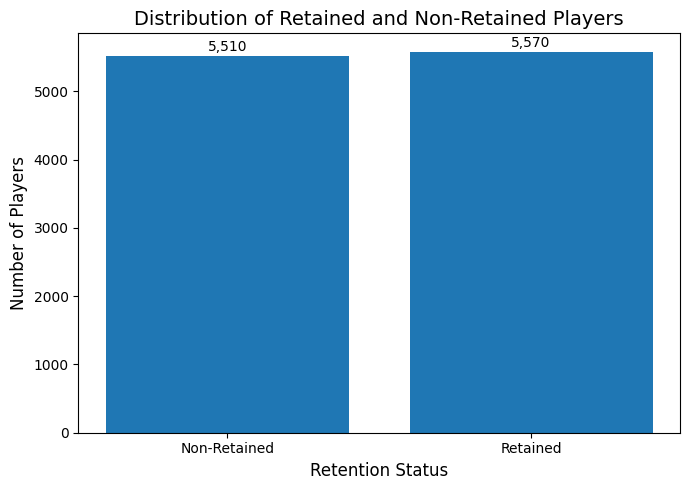

In [17]:
# Target distribution plot
plt.figure(figsize=(7, 5))

retention_counts = df["retained"].value_counts().sort_index()

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, retention_counts.values)

plt.title("Distribution of Retained and Non-Retained Players", fontsize=14)
plt.xlabel("Retention Status", fontsize=12)
plt.ylabel("Number of Players", fontsize=12)

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 40,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Engagement Analysis

This section examines whether player engagement during the first 24 hours differs between retained and non-retained players. Engagement is measured using login frequency, active days, and the average time gap between consecutive logins.

In [18]:
engagement_summary = (
    df.groupby("retained")["login_count_24h"]
      .agg(["mean", "median", "std"])
      .round(2)
)

engagement_summary.index = ["Non-Retained", "Retained"]

engagement_summary

,mean,median,std
Non-Retained,0.65,1.0,0.82
Retained,1.37,1.0,1.29


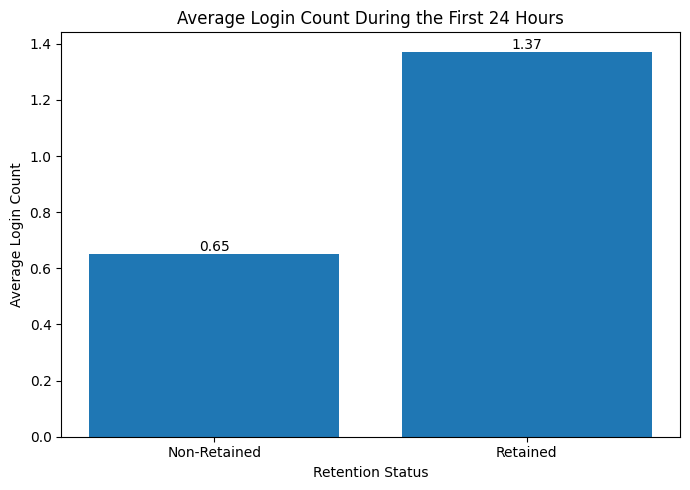

In [19]:
import matplotlib.pyplot as plt

avg_login = (
    df.groupby("retained")["login_count_24h"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_login)

plt.title("Average Login Count During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Login Count")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Active Days

This analysis compares the number of active days recorded during the first 24-hour observation window for retained and non-retained players.

In [20]:
active_days_summary = (
    df.groupby("retained")["active_days_24h"]
      .agg(["mean", "median", "std"])
      .round(2)
)

active_days_summary.index = ["Non-Retained", "Retained"]

active_days_summary

,mean,median,std
Non-Retained,0.54,1.0,0.56
Retained,0.91,1.0,0.64


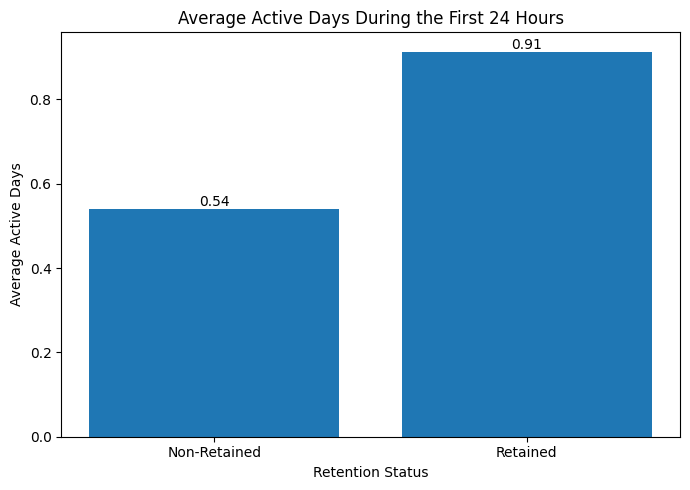

In [21]:
avg_active_days = (
    df.groupby("retained")["active_days_24h"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_active_days)

plt.title("Average Active Days During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Active Days")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Exploration Behaviour

This section investigates whether the extent of gameplay exploration during the first 24 hours differs between retained and non-retained players. Exploration is measured using the number of jobs initiated during the observation window.

In [22]:
jobs_started_summary = (
    df.groupby("retained")["jobs_started_24h"]
      .agg(["mean", "median", "std"])
      .round(2)
)

jobs_started_summary.index = ["Non-Retained", "Retained"]

jobs_started_summary

,mean,median,std
Non-Retained,1.49,0.0,4.08
Retained,3.31,2.0,4.79


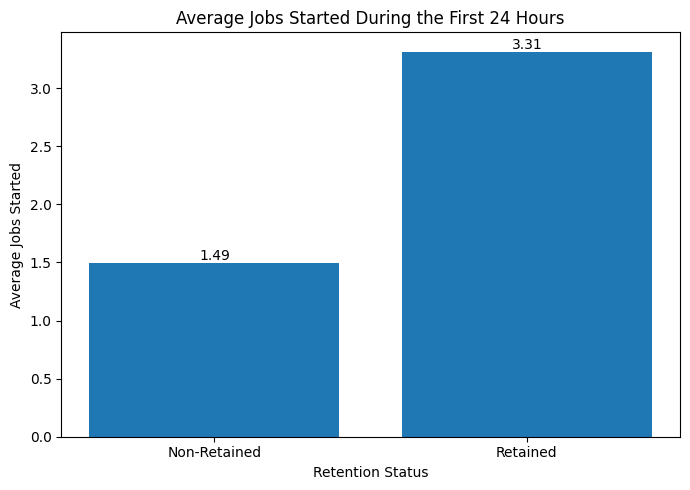

In [23]:
avg_jobs_started = (
    df.groupby("retained")["jobs_started_24h"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_jobs_started)

plt.title("Average Jobs Started During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Jobs Started")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [24]:
jobs_completed_summary = (
    df.groupby("retained")["jobs_completed_24h"]
      .agg(["mean", "median", "std"])
      .round(2)
)

jobs_completed_summary.index = ["Non-Retained", "Retained"]

jobs_completed_summary

,mean,median,std
Non-Retained,1.22,0.0,3.78
Retained,2.93,2.0,4.50


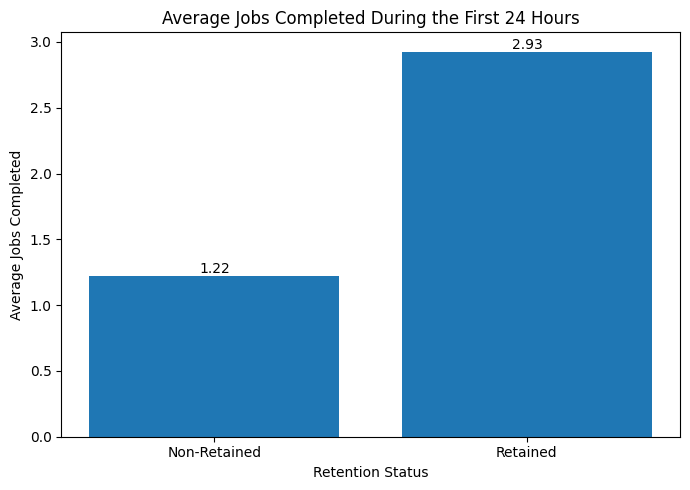

In [25]:
avg_jobs_completed = (
    df.groupby("retained")["jobs_completed_24h"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_jobs_completed)

plt.title("Average Jobs Completed During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Jobs Completed")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Task Completion

This analysis evaluates whether retained players completed more gameplay tasks during the first 24-hour observation window compared with non-retained players.

In [26]:
tasks_completed_summary = (
    df.groupby("retained")["tasks_completed_24h"]
      .agg(["mean", "median", "std"])
      .round(2)
)

tasks_completed_summary.index = ["Non-Retained", "Retained"]

tasks_completed_summary

,mean,median,std
Non-Retained,1.83,0.0,5.17
Retained,5.43,3.0,6.88


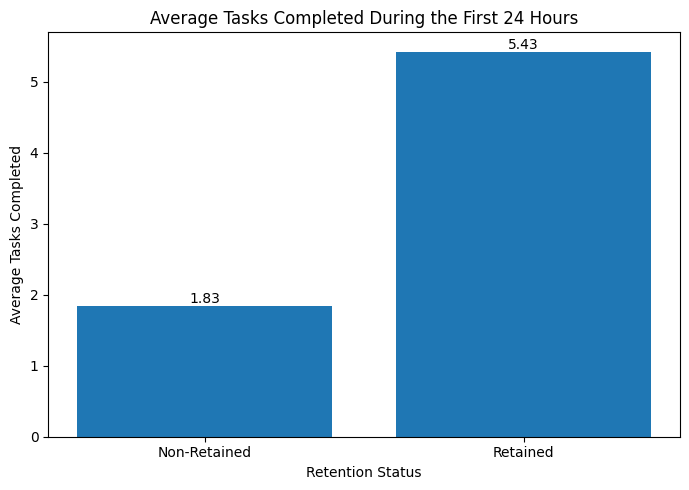

In [27]:
avg_tasks_completed = (
    df.groupby("retained")["tasks_completed_24h"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_tasks_completed)

plt.title("Average Tasks Completed During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Tasks Completed")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Subtask Completion

This analysis examines whether retained players completed more gameplay subtasks during the first 24-hour observation window than non-retained players. Subtasks represent the smallest measurable units of gameplay progression.

In [28]:
subtasks_completed_summary = (
    df.groupby("retained")["subtasks_completed_24h"]
      .agg(["mean", "median", "std"])
      .round(2)
)

subtasks_completed_summary.index = ["Non-Retained", "Retained"]

subtasks_completed_summary

,mean,median,std
Non-Retained,94.41,0.0,372.47
Retained,233.43,140.0,431.25


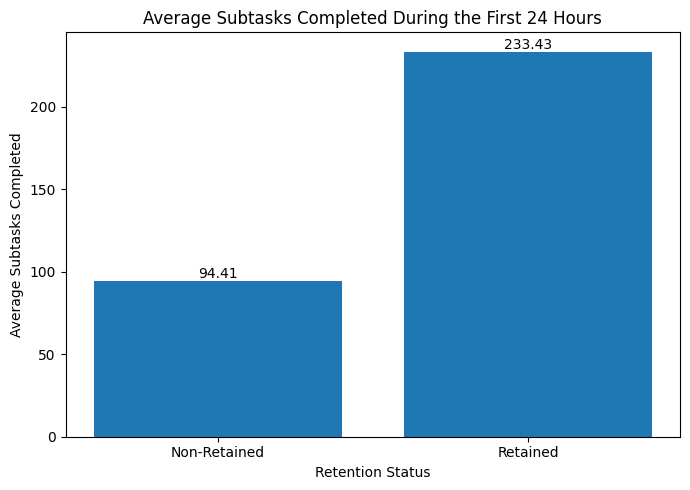

In [29]:
avg_subtasks_completed = (
    df.groupby("retained")["subtasks_completed_24h"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_subtasks_completed)

plt.title("Average Subtasks Completed During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Subtasks Completed")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Jobs Exited

This analysis examines whether retained and non-retained players differ in the number of gameplay sessions they exited during the first 24-hour observation window. Job exits provide insight into player persistence and session termination behaviour.

In [30]:
jobs_exited_summary = (
    df.groupby("retained")["jobs_exited_24h"]
      .agg(["mean", "median", "std"])
      .round(2)
)

jobs_exited_summary.index = ["Non-Retained", "Retained"]

jobs_exited_summary

,mean,median,std
Non-Retained,1.66,0.0,4.20
Retained,4.00,3.0,5.12


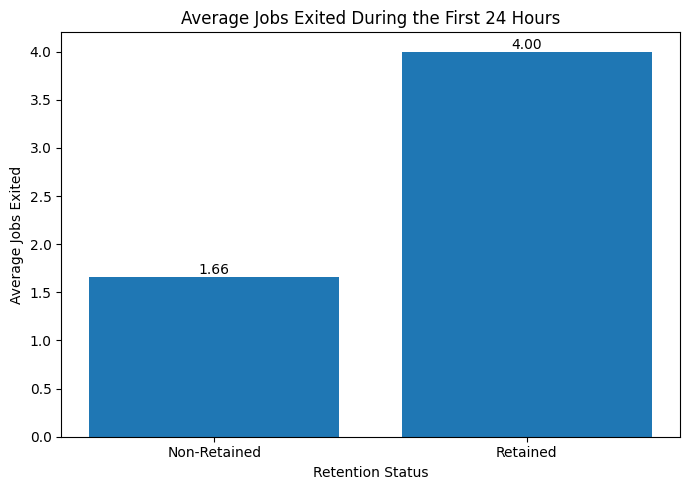

In [31]:
avg_jobs_exited = (
    df.groupby("retained")["jobs_exited_24h"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_jobs_exited)

plt.title("Average Jobs Exited During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Jobs Exited")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Average Session Length

This analysis compares the average gameplay session length during the first 24-hour observation window between retained and non-retained players. Session length reflects the amount of time players remain engaged during each gameplay session.

In [32]:
avg_session_length_summary = (
    df.groupby("retained")["avg_session_length"]
      .agg(["mean", "median", "std"])
      .round(2)
)

avg_session_length_summary.index = ["Non-Retained", "Retained"]

avg_session_length_summary

,mean,median,std
Non-Retained,15.98,0.0,62.50
Retained,44.49,16.0,88.66


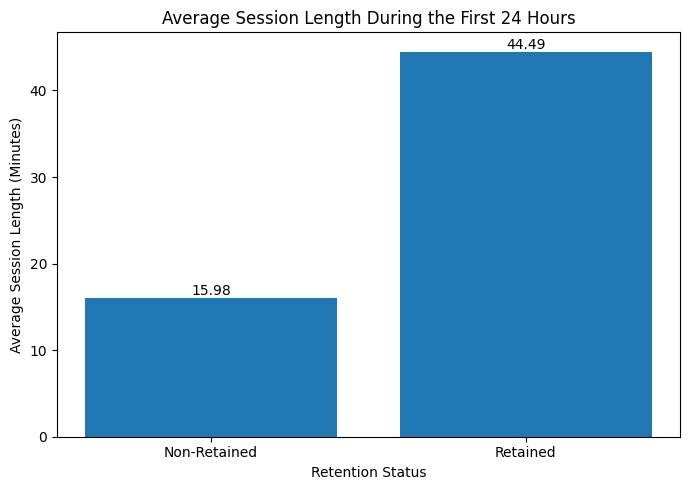

In [33]:
avg_session = (
    df.groupby("retained")["avg_session_length"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_session)

plt.title("Average Session Length During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Session Length (Minutes)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Maximum Session Length

This analysis compares the longest gameplay session recorded during the first 24-hour observation window for retained and non-retained players. Maximum session length reflects the player's highest level of continuous engagement.

In [34]:
max_session_length_summary = (
    df.groupby("retained")["max_session_length"]
      .agg(["mean", "median", "std"])
      .round(2)
)

max_session_length_summary.index = ["Non-Retained", "Retained"]

max_session_length_summary

,mean,median,std
Non-Retained,27.38,0.0,88.54
Retained,81.44,30.0,138.74


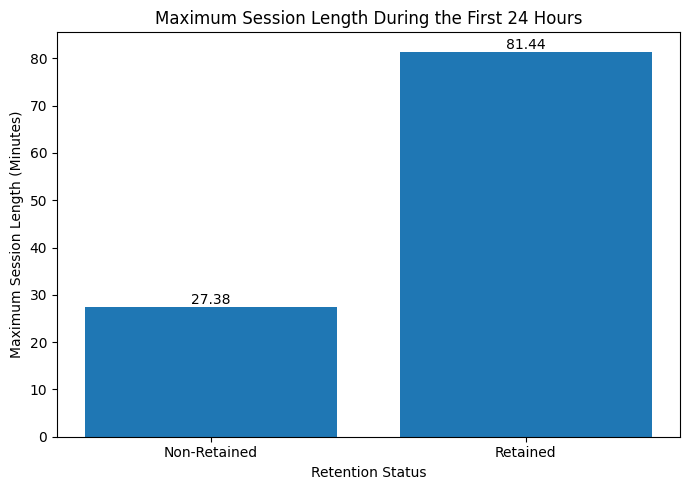

In [35]:
avg_max_session = (
    df.groupby("retained")["max_session_length"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_max_session)

plt.title("Maximum Session Length During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Maximum Session Length (Minutes)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Distinct Jobs Played

This analysis compares the number of unique jobs played during the first 24-hour observation window between retained and non-retained players. Distinct jobs played reflects the breadth of gameplay exploration rather than the total number of job starts.

In [36]:
distinct_jobs_summary = (
    df.groupby("retained")["distinct_jobs_played"]
      .agg(["mean", "median", "std"])
      .round(2)
)

distinct_jobs_summary.index = ["Non-Retained", "Retained"]

distinct_jobs_summary

,mean,median,std
Non-Retained,1.44,0.0,3.54
Retained,3.19,2.0,4.18


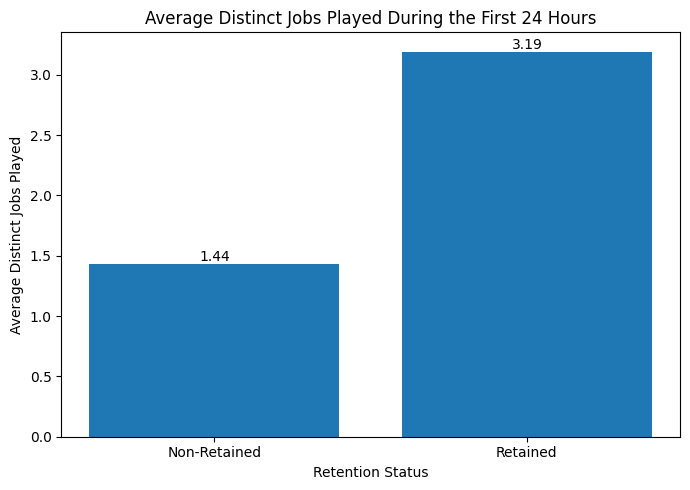

In [37]:
avg_distinct_jobs = (
    df.groupby("retained")["distinct_jobs_played"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_distinct_jobs)

plt.title("Average Distinct Jobs Played During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Distinct Jobs Played")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [38]:
df["interruption_count"].describe()

count    11080.000000
mean         2.836552
std          4.830954
min          0.000000
25%          0.000000
50%          2.000000
75%          4.000000
max         97.000000
Name: interruption_count, dtype: float64

In [39]:
df["distinct_jobs_played"].describe()

count    11080.000000
mean         2.318682
std          3.970758
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max         60.000000
Name: distinct_jobs_played, dtype: float64

In [40]:
(df["interruption_count"] == df["distinct_jobs_played"]).all()

False

In [41]:
interrupted_session_summary = (
    df.groupby("retained")["avg_interruption_session"]
      .agg(["mean", "median", "std"])
      .round(2)
)

interrupted_session_summary.index = ["Non-Retained", "Retained"]

interrupted_session_summary

,mean,median,std
Non-Retained,27.73,0.00,76.53
Retained,69.79,43.67,103.44


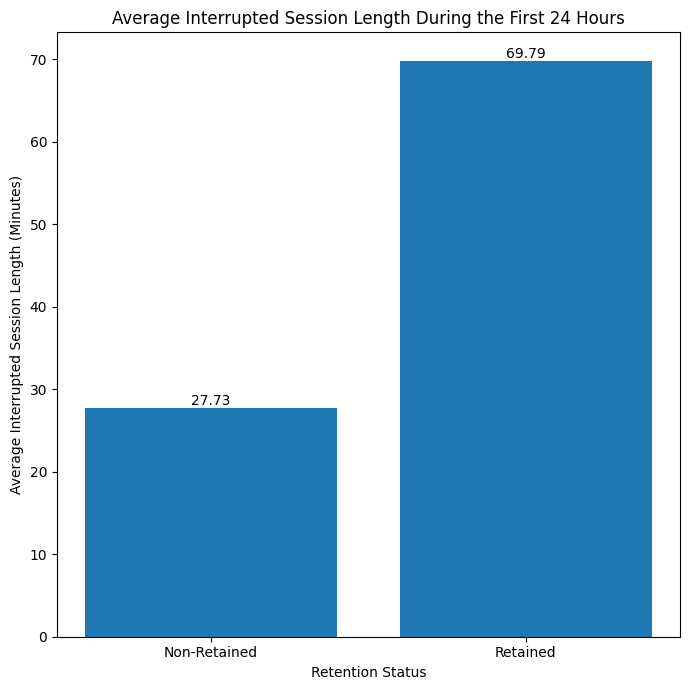

In [44]:
avg_interrupted_session = (
    df.groupby("retained")["avg_interruption_session"]
      .mean()
)

plt.figure(figsize=(7,7))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_interrupted_session)

plt.title("Average Interrupted Session Length During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Interrupted Session Length (Minutes)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Longest Interrupted Session

This analysis compares the longest interrupted gameplay session recorded during the first 24-hour observation window between retained and non-retained players. This feature reflects the player's highest level of continuous engagement prior to an interruption.

In [45]:
longest_interruption_summary = (
    df.groupby("retained")["longest_interrupted_session"]
      .agg(["mean", "median", "std"])
      .round(2)
)

longest_interruption_summary.index = ["Non-Retained", "Retained"]

longest_interruption_summary

,mean,median,std
Non-Retained,42.46,0.0,106.83
Retained,118.32,70.0,159.41


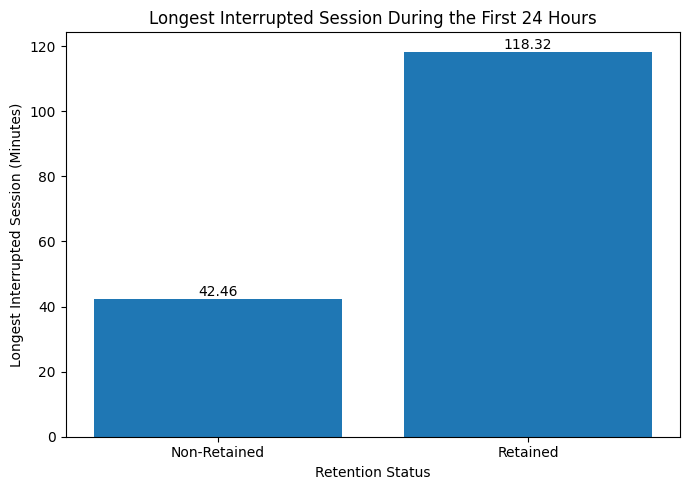

In [46]:
avg_longest_interruption = (
    df.groupby("retained")["longest_interrupted_session"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_longest_interruption)

plt.title("Longest Interrupted Session During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Longest Interrupted Session (Minutes)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Career Play Ratio

This analysis compares the proportion of gameplay sessions spent in Career mode during the first 24-hour observation window between retained and non-retained players. Career Play Ratio reflects the extent to which players focused on the game's primary progression mode.

In [47]:
career_ratio_summary = (
    df.groupby("retained")["career_play_ratio"]
      .agg(["mean", "median", "std"])
      .round(3)
)

career_ratio_summary.index = ["Non-Retained", "Retained"]

career_ratio_summary

,mean,median,std
Non-Retained,0.399,0.0,0.482
Retained,0.677,1.0,0.451


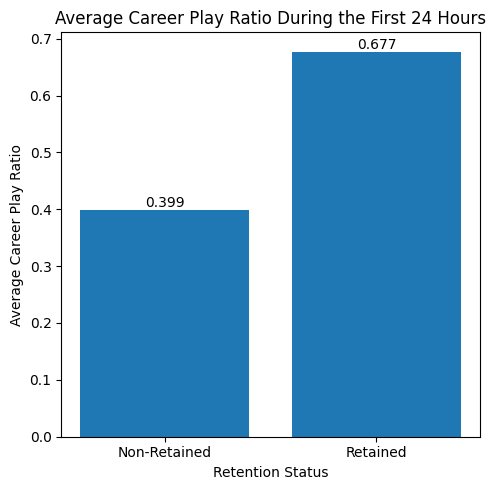

In [50]:
avg_career_ratio = (
    df.groupby("retained")["career_play_ratio"]
      .mean()
)

plt.figure(figsize=(5,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_career_ratio)

plt.title("Average Career Play Ratio During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Career Play Ratio")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Special Play Ratio

This analysis compares the proportion of gameplay sessions spent in Special mode during the first 24-hour observation window between retained and non-retained players. Special Play Ratio reflects the extent to which players engaged with special jobs relative to other game modes.

In [51]:
special_ratio_summary = (
    df.groupby("retained")["special_play_ratio"]
      .agg(["mean", "median", "std"])
      .round(3)
)

special_ratio_summary.index = ["Non-Retained", "Retained"]

special_ratio_summary

,mean,median,std
Non-Retained,0.023,0.0,0.128
Retained,0.033,0.0,0.146


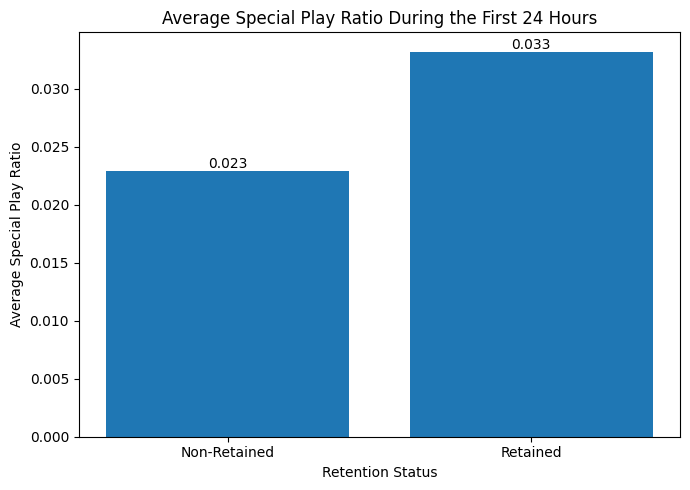

In [52]:
avg_special_ratio = (
    df.groupby("retained")["special_play_ratio"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_special_ratio)

plt.title("Average Special Play Ratio During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Special Play Ratio")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Freeplay Ratio

This analysis compares the proportion of gameplay sessions spent in Freeplay mode during the first 24-hour observation window between retained and non-retained players. Freeplay Ratio reflects the extent to which players engaged with unrestricted gameplay relative to other game modes.

In [53]:
freeplay_ratio_summary = (
    df.groupby("retained")["freeplay_ratio"]
      .agg(["mean", "median", "std"])
      .round(3)
)

freeplay_ratio_summary.index = ["Non-Retained", "Retained"]

freeplay_ratio_summary

,mean,median,std
Non-Retained,0.004,0.0,0.049
Retained,0.009,0.0,0.062


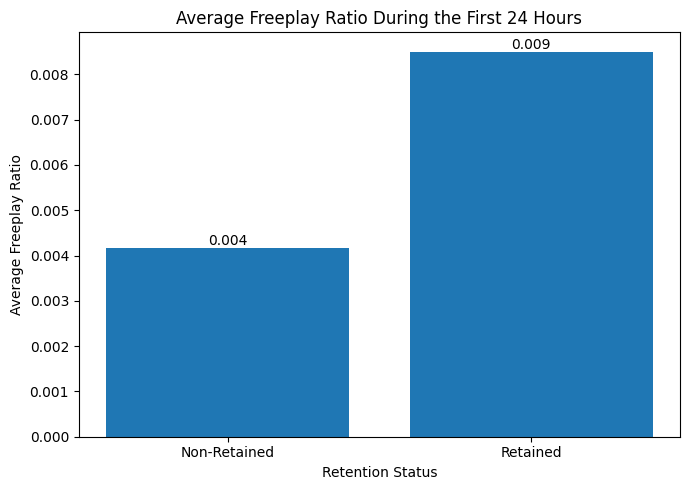

In [54]:
avg_freeplay_ratio = (
    df.groupby("retained")["freeplay_ratio"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_freeplay_ratio)

plt.title("Average Freeplay Ratio During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Freeplay Ratio")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Challenge Play Ratio

This analysis compares the proportion of gameplay sessions spent in Challenge mode during the first 24-hour observation window between retained and non-retained players. Challenge Play Ratio reflects the extent to which players engaged with challenge-based gameplay relative to other game modes.

In [56]:
challenge_ratio_summary = (
    df.groupby("retained")["challenge_ratio"]
      .agg(["mean", "median", "std"])
      .round(3)
)

challenge_ratio_summary.index = ["Non-Retained", "Retained"]

challenge_ratio_summary

,mean,median,std
Non-Retained,0.001,0.0,0.023
Retained,0.002,0.0,0.029


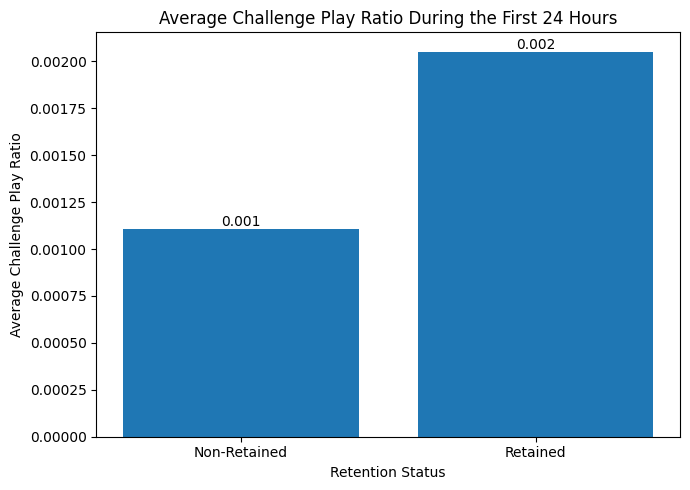

In [57]:
avg_challenge_ratio = (
    df.groupby("retained")["challenge_ratio"]
      .mean()
)

plt.figure(figsize=(7,5))

labels = ["Non-Retained", "Retained"]

bars = plt.bar(labels, avg_challenge_ratio)

plt.title("Average Challenge Play Ratio During the First 24 Hours")
plt.xlabel("Retention Status")
plt.ylabel("Average Challenge Play Ratio")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()